In [6]:
# netflix.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mymoviedb.csv', encoding='latin1', engine='python', on_bad_lines='skip')
print(df.head())
print(df.tail())


  Release_Date                    Title  \
0   2021-12-15  Spider-Man: No Way Home   
1   2022-03-01               The Batman   
2   2022-02-25                  No Exit   
3   2021-11-24                  Encanto   
4   2021-12-22           The King's Man   

                                            Overview  Popularity Vote_Count  \
0  Peter Parker is unmasked and no longer able to...    5083.954       8940   
1  In his second year of fighting crime, Batman u...    3827.658       1151   
2  Stranded at a rest stop in the mountains durin...    2618.087        122   
3  The tale of an extraordinary family, the Madri...    2402.201       5076   
4  As a collection of history's worst tyrants and...    1895.511       1793   

  Vote_Average Original_Language                               Genre  \
0          8.3                en  Action, Adventure, Science Fiction   
1          8.1                en            Crime, Mystery, Thriller   
2          6.3                en                  

In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [8]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [9]:
df.duplicated().sum()  # Check for duplicate rows

np.int64(0)

In [11]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
print(df['Release_Date'].dtypes)
print(df['Release_Date'].dtypes)

datetime64[ns]
datetime64[ns]


In [12]:
df['Release_Date']=df['Release_Date'].dt.year
print(df['Release_Date'].dtypes)

float64


In [13]:
df.head(10)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021.0,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022.0,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022.0,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021.0,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021.0,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
5,2022.0,The Commando,An elite DEA agent returns home after a failed...,1750.484,33,6.6,en,"Action, Crime, Thriller",https://image.tmdb.org/t/p/original/pSh8MyYu5C...
6,2022.0,Scream,Twenty-five years after a streak of brutal mur...,1675.161,821,6.8,en,"Horror, Mystery, Thriller",https://image.tmdb.org/t/p/original/kZNHR1upJK...
7,2022.0,Kimi,A tech worker with agoraphobia discovers recor...,1601.782,206,6.3,en,Thriller,https://image.tmdb.org/t/p/original/okNgwtxIWz...
8,2022.0,Fistful of Vengeance,A revenge mission becomes a fight to save the ...,1594.013,114,5.3,en,"Action, Crime, Fantasy",https://image.tmdb.org/t/p/original/3cccEF9QZg...
9,2021.0,Eternals,The Eternals are a team of ancient aliens who ...,1537.406,4726,7.2,en,Science Fiction,https://image.tmdb.org/t/p/original/zByhtBvX99...


In [15]:
cols = ['Overview', 'Original_Language', 'Poster_Url']
df.drop(cols, axis=1, inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [16]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122,6.3,Thriller
3,2021.0,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [17]:

def categorize_col(df,col,labels):
    edge=df[col] .desribe()['min'],df[col].describe()['max']
    edge=df[col] .desribe()['25%'],df[col].describe()['75%']
    df[col]=pd.cut(df[col],edge,labels=labels,duplicates='drop')
    return df

In [19]:
labels = ['not_popular', 'below_avg', 'average', 'popolar']
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')
quantiles = df['Vote_Average'].quantile([0, 0.25, 0.5, 0.75, 1]).values
df['Vote_Average_Category'] = pd.cut(df['Vote_Average'], bins=quantiles, labels=labels, include_lowest=True, duplicates='drop')
df[['Vote_Average', 'Vote_Average_Category']].head()

,Vote_Average,Vote_Average_Category
0,8.3,popolar
1,8.1,popolar
2,6.3,below_avg
3,7.7,popolar
4,7.0,average


In [20]:
df['Vote_Average_Category'].value_counts()

Vote_Average_Category
not_popular    2567
popolar        2450
average        2411
below_avg      2398
Name: count, dtype: int64

In [21]:
df.dropna(inplace=True) # Remove rows with NaN values
df.isna().sum()  # Check for NaN values after dropping

Release_Date             0
Title                    0
Popularity               0
Vote_Count               0
Vote_Average             0
Genre                    0
Vote_Average_Category    0
dtype: int64

In [22]:
#casting column into category
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Action, Adventure',
                  'Action, Adventure, Animation',
                  'Action, Adventure, Animation, Comedy',
                  'Action, Adventure, Animation, Comedy, Family',
                  'Action, Adventure, Animation, Comedy, Romance',
                  'Action, Adventure, Animation, Crime, Family, Mystery',
                  'Action, Adventure, Animation, Drama',
                  'Action, Adventure, Animation, Family',
                  'Action, Adventure, Animation, Family, Comedy',
                  ...
                  'Western, Drama', 'Western, Drama, Action, Adventure',
                  'Western, Drama, Adventure', 'Western, Drama, Crime',
                  'Western, Drama, History', 'Western, Drama, Mystery',
                  'Western, History', 'Western, Horror',
                  'Western, Mystery, Thriller, Drama', 'Western, Thriller'],
, ordered=False, categories_dtype=object)

In [23]:
df.nunique()

Release_Date              102
Title                    9512
Popularity               8159
Vote_Count               3266
Vote_Average               74
Genre                    2337
Vote_Average_Category       4
dtype: int64

In [24]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
0,2021.0,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",popolar
1,2022.0,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",popolar
2,2022.0,No Exit,2618.087,122,6.3,Thriller,below_avg
3,2021.0,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",popolar
4,2021.0,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",average


In [25]:
df['Genre'].describe()

count      9826
unique     2337
top       Drama
freq        466
Name: Genre, dtype: object

In [29]:
sns.set_style("whitegrid")

In [27]:
df['Genre'].describe()

count      9826
unique     2337
top       Drama
freq        466
Name: Genre, dtype: object

In [28]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
0,2021.0,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",popolar
1,2022.0,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",popolar
2,2022.0,No Exit,2618.087,122,6.3,Thriller,below_avg
3,2021.0,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",popolar
4,2021.0,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",average


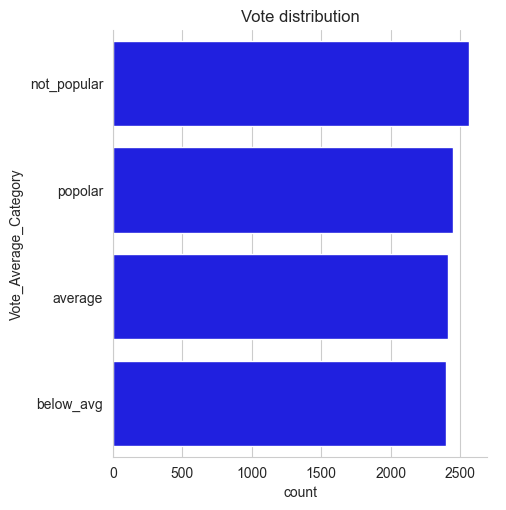

In [30]:
labels = ['not_popular', 'below_avg', 'average', 'popolar']
quantiles = df['Vote_Average'].quantile([0, 0.25, 0.5, 0.75, 1]).values
df['Vote_Average_Category'] = pd.cut(df['Vote_Average'], bins=quantiles, labels=labels, include_lowest=True, duplicates='drop')

sns.catplot(y='Vote_Average_Category', data=df, kind='count',
            order=df['Vote_Average_Category'].value_counts().index,
            color='blue')
plt.title('Vote distribution')
plt.show()

In [31]:
df.head(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
0,2021.0,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",popolar
1,2022.0,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",popolar
2,2022.0,No Exit,2618.087,122,6.3,Thriller,below_avg
3,2021.0,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",popolar
4,2021.0,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",average


In [32]:
df[df['Popularity'] ==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
0,2021.0,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",popolar


In [33]:
df[df['Popularity'] ==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
9835,2021.0,The United States vs. Billie Holiday,13.354,152,6.7,"Music, Drama, History",average
9836,1984.0,Threads,13.354,186,7.8,"War, Drama, Science Fiction",popolar


In [34]:
df['Release_Date'].describe()

count    9826.000000
mean     2006.202931
std        15.686202
min      1902.000000
25%      2000.000000
50%      2011.000000
75%      2017.000000
max      2024.000000
Name: Release_Date, dtype: float64

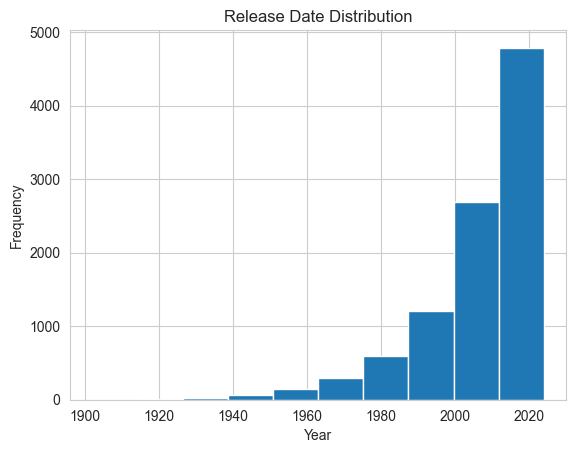

In [35]:
df['Release_Date'].hist()
plt.title('Release Date Distribution')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

In [36]:
df.describe(include='all')

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
count,9826.000000,9826,9826.000000,9826,9826.000000,9826,9826
unique,NaN,9512,NaN,3266,NaN,2337,4
top,NaN,Beauty and the Beast,NaN,0,NaN,Drama,not_popular
freq,NaN,4,NaN,100,NaN,466,2567
mean,2006.202931,NaN,40.323951,NaN,6.439467,NaN,NaN
std,15.686202,NaN,108.879332,NaN,1.129797,NaN,NaN
min,1902.000000,NaN,13.354000,NaN,0.000000,NaN,NaN
25%,2000.000000,NaN,16.128250,NaN,5.900000,NaN,NaN
50%,2011.000000,NaN,21.195000,NaN,6.500000,NaN,NaN
75%,2017.000000,NaN,35.179250,NaN,7.100000,NaN,NaN


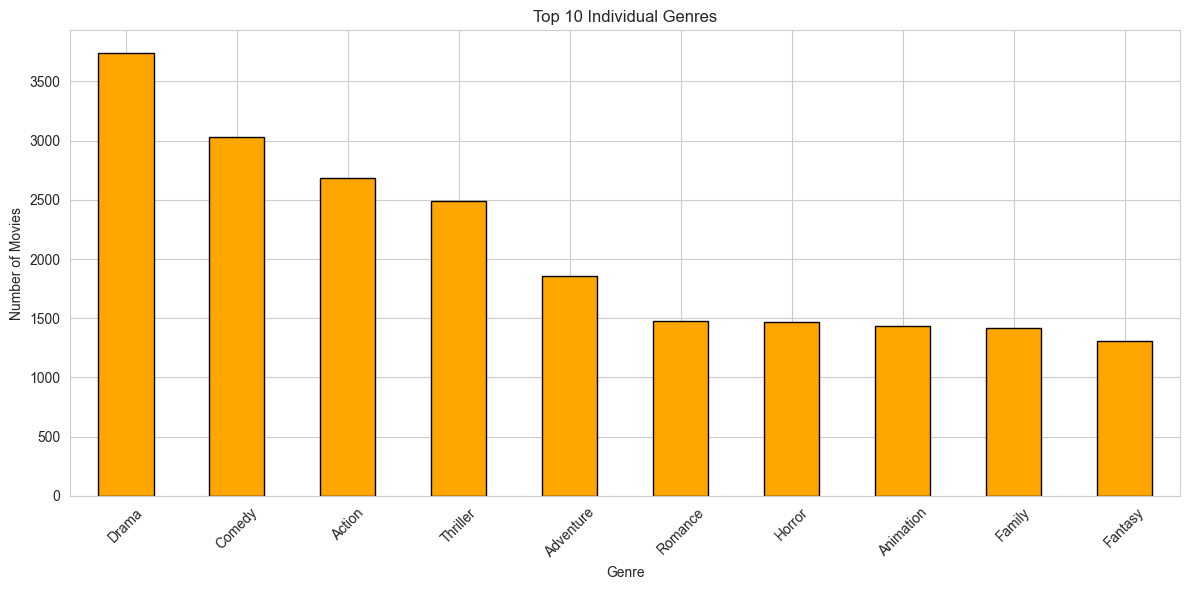

In [46]:
genre = df['Genre'].str.split(', ').explode()

plt.figure(figsize=(12,6))

genre.value_counts().head(10).plot(
    kind='bar',
    color='orange',
    edgecolor='black'
)

plt.title("Top 10 Individual Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()